In [1]:
import os
from time import sleep
import pandas as pd
import json
from requests import session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import seaborn as sns
import matplotlib.pyplot as plt

def api_runner():
    global df
    
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    
    parameters = {
        'start': '1',
        'limit': '20',
        'convert': 'USD'
    }
    
    Headers = {
        'Accept': 'application/json',
        'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }
    
    session_obj = session()
    session_obj.headers.update(Headers)
    
    try:
        response = session_obj.get(url, params=parameters)
        data = json.loads(response.text)
        print("Status code:", response.status_code)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
        print(e)
        return
    
    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    
    # Modern och säker append
    df = pd.concat([df, df2], ignore_index=True)
    
    # Save to CSV
    file_path = r'C:\Users\wijks\Documents\Data Analyst Portfolio\Crypto Checker Api Project\csv\API.csv'
    
    if not os.path.isfile(file_path):
        df.to_csv(file_path, index=False)
    else:
        df.to_csv(file_path, mode='a', header=False, index=False)
    
    print(f"Data appended at {pd.to_datetime('now')}")

In [2]:
# Initialize
df = pd.json_normalize(data['data']) if 'data' in globals() else pd.DataFrame()
df['timestamp'] = pd.to_datetime('now')
print("Initial df created with", len(df), "rows")

Initial df created with 0 rows


In [3]:
import os
from time import sleep

for i in range(5):          # 5 iterations for this test (MAX 333/day)
    api_runner()
    print(f'API Runner Completed Successfully - Iteration {i+1}')
    sleep(60)  # 1 minut

Status code: 200
Data appended at 2026-07-24 14:32:55.347230
API Runner Completed Successfully - Iteration 1
Status code: 200
Data appended at 2026-07-24 14:33:55.521761
API Runner Completed Successfully - Iteration 2
Status code: 200
Data appended at 2026-07-24 14:34:55.690478
API Runner Completed Successfully - Iteration 3
Status code: 200
Data appended at 2026-07-24 14:35:55.855413
API Runner Completed Successfully - Iteration 4
Status code: 200
Data appended at 2026-07-24 14:36:56.030089
API Runner Completed Successfully - Iteration 5


In [4]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
df

,timestamp,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,...,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address
0,2026-07-24 14:32:55.341632,1.00000,Bitcoin,BTC,bitcoin,False,20060671.00000,20060671.00000,21000000.00000,2010-07-13T00:00:00.000Z,...,1303486059369.29541,58.90150,1364521019598.76001,None,2026-07-24T12:30:00.000Z,NaN,NaN,NaN,NaN,NaN
1,2026-07-24 14:32:55.341632,1027.00000,Ethereum,ETH,ethereum,True,120682712.41642,120682712.41642,NaN,2015-08-07T00:00:00.000Z,...,227101693234.52435,10.25860,227101693234.51999,None,2026-07-24T12:32:00.000Z,NaN,NaN,NaN,NaN,NaN
2,2026-07-24 14:32:55.341632,825.00000,Tether USDt,USDT,tether,True,184156916986.16385,189106724037.45197,NaN,2015-02-25T00:00:00.000Z,...,184003031177.97079,8.31220,188948702055.22000,None,2026-07-24T12:31:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7
3,2026-07-24 14:32:55.341632,1839.00000,BNB,BNB,bnb,False,133165746.73000,133165746.73000,133165746.73000,2017-07-25T00:00:00.000Z,...,75352781104.09354,3.40400,75352781104.09000,None,2026-07-24T12:32:00.000Z,NaN,NaN,NaN,NaN,NaN
4,2026-07-24 14:32:55.341632,3408.00000,USDC,USDC,usd-coin,False,72978910168.95134,72978910168.95134,NaN,2018-10-08T00:00:00.000Z,...,72963626017.53011,3.29590,72963626017.53000,None,2026-07-24T12:30:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-07-24 14:36:56.023571,2010.00000,Cardano,ADA,cardano,False,36489899411.97189,44993202652.38657,45000000000.00000,2017-10-01T00:00:00.000Z,...,6063385407.75494,0.27400,7477475897.33000,None,2026-07-24T12:35:00.000Z,NaN,NaN,NaN,NaN,NaN
96,2026-07-24 14:36:56.023571,37263.00000,Canton,CC,canton-network,True,39145141881.92199,39145141881.92199,NaN,2025-07-08T04:07:45.000Z,...,4689335345.22326,0.21190,4689335345.22000,None,2026-07-24T12:35:00.000Z,NaN,NaN,NaN,NaN,NaN
97,2026-07-24 14:36:56.023571,4943.00000,Dai,DAI,multi-collateral-dai,True,4647076141.40391,4647076141.40391,NaN,2019-11-22T00:00:00.000Z,...,4645905844.72760,0.20990,4645905844.73000,None,2026-07-24T12:35:00.000Z,1027.00000,ethereum,Ethereum,ETH,0x6b175474e89094c44da98b954eedeac495271d0f
98,2026-07-24 14:36:56.023571,1831.00000,Bitcoin Cash,BCH,bitcoin-cash,False,20065618.75000,20065618.75000,21000000.00000,2017-07-23T00:00:00.000Z,...,4222370939.73641,0.19090,4418991053.26000,None,2026-07-24T12:34:00.000Z,NaN,NaN,NaN,NaN,NaN


In [5]:
# Grouping
df3 = df.groupby('name', sort = False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h', 'quote.USD.percent_change_7d', 'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d', 'quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.00371,-0.55983,2.92193,3.60029,-15.96913,-16.27049
Ethereum,0.10013,-1.73415,2.67661,12.40119,-11.08139,-18.72749
Tether USDt,-0.01619,-0.02984,0.01075,0.04585,0.01735,-0.08829
BNB,0.00766,-0.63715,0.56411,-2.06239,-15.31622,-10.84555
USDC,-0.01573,-0.00080,-0.00202,0.00652,0.02197,0.01501
XRP,0.00999,-2.24212,2.13281,1.19153,-18.68334,-22.83760
Solana,-0.13033,-2.99252,0.76207,7.90705,-12.50760,-13.00312
TRON,-0.12458,1.31896,2.64591,0.01134,-9.97373,2.50366
Hyperliquid,0.13053,-1.56914,-2.63580,-5.94486,-7.24361,40.65453


In [6]:
# Stacking
df4 = df3.stack()
df4

name                                                     
Bitcoin                      quote.USD.percent_change_1h     -0.00371
                             quote.USD.percent_change_24h    -0.55983
                             quote.USD.percent_change_7d      2.92193
                             quote.USD.percent_change_30d     3.60029
                             quote.USD.percent_change_60d   -15.96913
                                                               ...   
World Liberty Financial USD  quote.USD.percent_change_24h    -0.02496
                             quote.USD.percent_change_7d     -0.01737
                             quote.USD.percent_change_30d    -0.02776
                             quote.USD.percent_change_60d    -0.00804
                             quote.USD.percent_change_90d    -0.09906
Length: 120, dtype: float64

In [7]:
df5 = df4.to_frame(name = 'values')
df5

values
name                                                              
Bitcoin                     quote.USD.percent_change_1h   -0.00371
                            quote.USD.percent_change_24h  -0.55983
                            quote.USD.percent_change_7d    2.92193
                            quote.USD.percent_change_30d   3.60029
                            quote.USD.percent_change_60d -15.96913
...                                                            ...
World Liberty Financial USD quote.USD.percent_change_24h  -0.02496
                            quote.USD.percent_change_7d   -0.01737
                            quote.USD.percent_change_30d  -0.02776
                            quote.USD.percent_change_60d  -0.00804
                            quote.USD.percent_change_90d  -0.09906

[120 rows x 1 columns]

In [8]:
df5.count()

values    120
dtype: int64

In [9]:
# Give index

index = pd.Index(range(120))

#df6 = df5.set_index(index)
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.00371
1,Bitcoin,quote.USD.percent_change_24h,-0.55983
2,Bitcoin,quote.USD.percent_change_7d,2.92193
3,Bitcoin,quote.USD.percent_change_30d,3.60029
4,Bitcoin,quote.USD.percent_change_60d,-15.96913
...,...,...,...
115,World Liberty Financial USD,quote.USD.percent_change_24h,-0.02496
116,World Liberty Financial USD,quote.USD.percent_change_7d,-0.01737
117,World Liberty Financial USD,quote.USD.percent_change_30d,-0.02776
118,World Liberty Financial USD,quote.USD.percent_change_60d,-0.00804


In [10]:
df7 = df6.rename(columns = {'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.00371
1,Bitcoin,quote.USD.percent_change_24h,-0.55983
2,Bitcoin,quote.USD.percent_change_7d,2.92193
3,Bitcoin,quote.USD.percent_change_30d,3.60029
4,Bitcoin,quote.USD.percent_change_60d,-15.96913
...,...,...,...
115,World Liberty Financial USD,quote.USD.percent_change_24h,-0.02496
116,World Liberty Financial USD,quote.USD.percent_change_7d,-0.01737
117,World Liberty Financial USD,quote.USD.percent_change_30d,-0.02776
118,World Liberty Financial USD,quote.USD.percent_change_60d,-0.00804


In [11]:
# Cleaning up percent_change values
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.00371
1,Bitcoin,24h,-0.55983
2,Bitcoin,7d,2.92193
3,Bitcoin,30d,3.60029
4,Bitcoin,60d,-15.96913
...,...,...,...
115,World Liberty Financial USD,24h,-0.02496
116,World Liberty Financial USD,7d,-0.01737
117,World Liberty Financial USD,30d,-0.02776
118,World Liberty Financial USD,60d,-0.00804


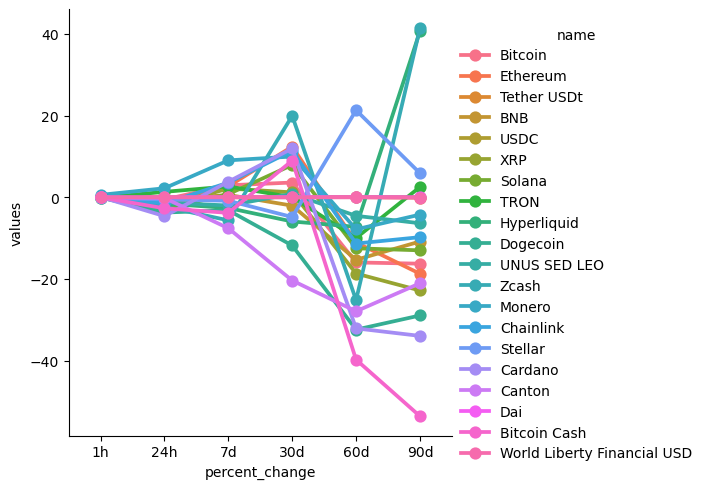

In [12]:
# Visualization
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [13]:
# See price change for wished for coin/crypto from API Runner
df10 = df[['name', 'quote.USD.price', 'timestamp']].query("name == 'Dogecoin'") # change this crypto name to see viz below
print(df10)

        name  quote.USD.price                  timestamp
9   Dogecoin          0.06953 2026-07-24 14:32:55.341632
29  Dogecoin          0.06953 2026-07-24 14:33:55.516418
49  Dogecoin          0.06953 2026-07-24 14:34:55.684841
69  Dogecoin          0.06955 2026-07-24 14:35:55.848719
89  Dogecoin          0.06954 2026-07-24 14:36:56.023571


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

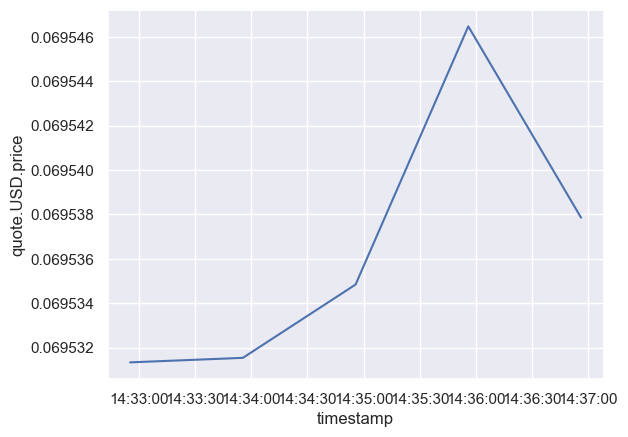

In [14]:
# Visualization of coin above
sns.set_theme(style = "darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)